# Filter the Video 

In [3]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# === INPUT & OUTPUT PATHS ===
input_path = "data/group_11_fixed.mp4"      # path to your original video
output_path = "output/group_11_fixed__Gaussianblur.mp4"  # where to save the filtered video

# === READ INPUT VIDEO ===
cap = cv2.VideoCapture(input_path)
if not cap.isOpened():
    raise IOError("Error: cannot open video file!")

# === GET VIDEO PROPERTIES ===
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_size = (width, height)

# === DEFINE VIDEO WRITER ===
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, frame_size)

# === FRAME-BY-FRAME PROCESSING ===
while True:
    ret, frame = cap.read()
    if not ret:
        break  # no more frames

    # --- Apply filter (example: Gaussian blur) ---
    filtered_frame = cv2.GaussianBlur(frame, (5, 5), 0)
    
    # Optional: you could use other filters:
    # filtered_frame = cv2.medianBlur(frame, 5)
    # filtered_frame = cv2.bilateralFilter(frame, 9, 75, 75)

    # --- Write the filtered frame ---
    out.write(filtered_frame)

# === CLEAN UP ===
cap.release()
out.release()

print("✅ Filtered video saved successfully at:", output_path)


✅ Filtered video saved successfully at: output/group_11_fixed__Gaussianblur.mp4


- Conclusion no need for simple filtering bluring etc.. , The video is already clean. Adding filtering at this stage might be unnecessary. To check it lets look at the frequency domain of the entire fixed video. 


Video array shape: (128, 128, 128)


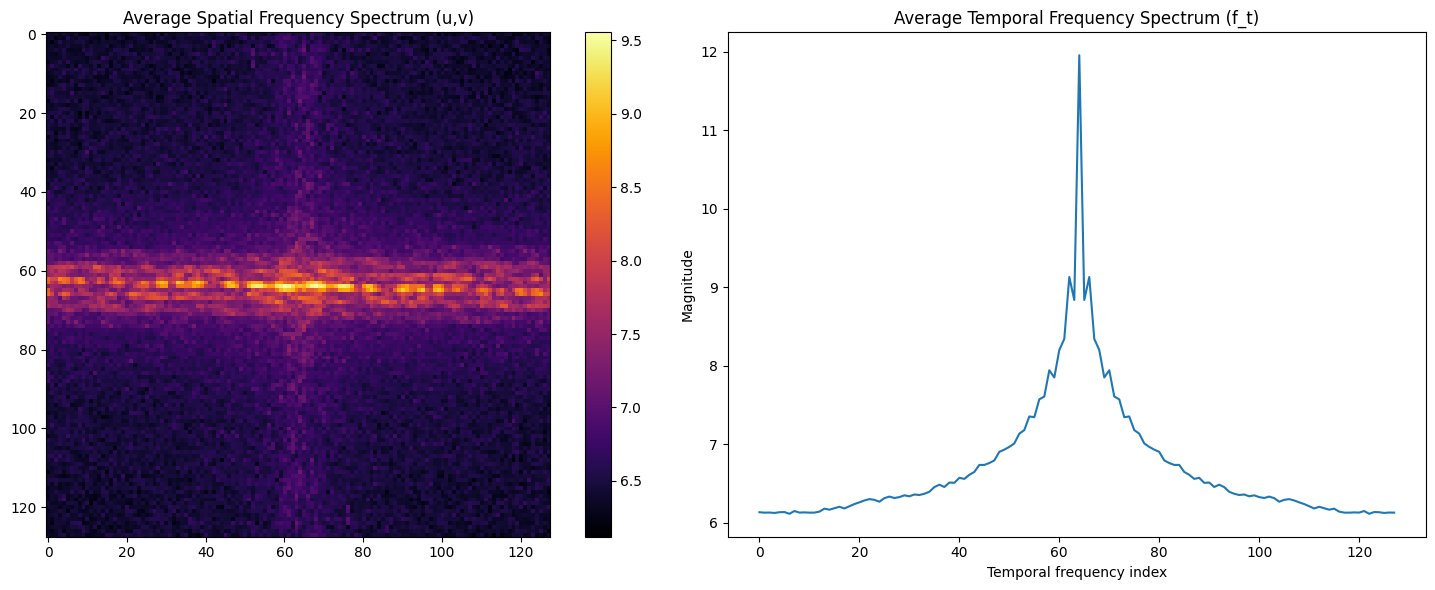

In [ ]:
video_path = "data/group_11_fixed.mp4"  
cap = cv2.VideoCapture(video_path)

frames = []
frame_count = 0
max_frames = 128  # limit to 128 frames for efficiency

while True:
    ret, frame = cap.read()
    if not ret or frame_count >= max_frames:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (128, 128))
    frames.append(gray)
    frame_count += 1

cap.release()

video_array = np.stack(frames, axis=0)  # shape (T, H, W)
print(f"Video array shape: {video_array.shape}")

# --- Compute 3D FFT ---
fft3d = np.fft.fftn(video_array)
fft3d_shifted = np.fft.fftshift(fft3d)
magnitude = np.log(np.abs(fft3d_shifted) + 1e-8)

# --- Compute projections ---
# Average over time to see spatial frequency distribution
spatial_spectrum = np.mean(magnitude, axis=0)

# Average over space to see temporal frequency distribution
temporal_spectrum = np.mean(np.mean(magnitude, axis=1), axis=1)

# --- Visualize ---
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(spatial_spectrum, cmap='inferno')
plt.title('Average Spatial Frequency Spectrum (u,v)')
plt.colorbar()

plt.subplot(1,2,2)
plt.plot(temporal_spectrum)
plt.title('Average Temporal Frequency Spectrum (f_t)')
plt.xlabel('Temporal frequency index')
plt.ylabel('Magnitude')

plt.tight_layout()
plt.show()


Video array shape: (128, 128, 128)


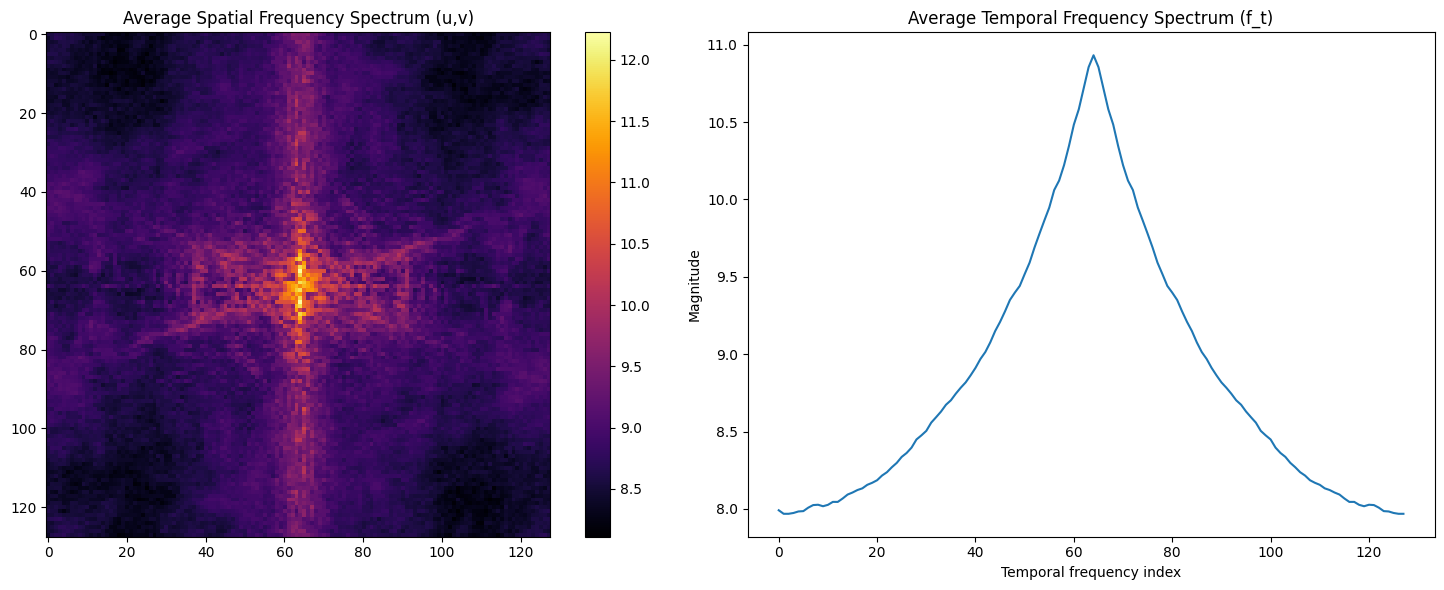

In [8]:
video_path = "data/group_11_dynamic.mp4"  
cap = cv2.VideoCapture(video_path)

frames = []
frame_count = 0
max_frames = 128  # limit to 128 frames for efficiency

while True:
    ret, frame = cap.read()
    if not ret or frame_count >= max_frames:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (128, 128))
    frames.append(gray)
    frame_count += 1

cap.release()

video_array = np.stack(frames, axis=0)  # shape (T, H, W)
print(f"Video array shape: {video_array.shape}")

# --- Compute 3D FFT ---
fft3d = np.fft.fftn(video_array)
fft3d_shifted = np.fft.fftshift(fft3d)
magnitude = np.log(np.abs(fft3d_shifted) + 1e-8)

# --- Compute projections ---
# Average over time to see spatial frequency distribution
spatial_spectrum = np.mean(magnitude, axis=0)

# Average over space to see temporal frequency distribution
temporal_spectrum = np.mean(np.mean(magnitude, axis=1), axis=1)

# --- Visualize ---
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(spatial_spectrum, cmap='inferno')
plt.title('Average Spatial Frequency Spectrum (u,v)')
plt.colorbar()

plt.subplot(1,2,2)
plt.plot(temporal_spectrum)
plt.title('Average Temporal Frequency Spectrum (f_t)')
plt.xlabel('Temporal frequency index')
plt.ylabel('Magnitude')

plt.tight_layout()
plt.show()


# Canny edge detector ? 

In [9]:
import cv2

input_path = "data/group_11_fixed.mp4"
output_path = "output/edges_output.mp4"

cap = cv2.VideoCapture(input_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
w, h = int(cap.get(3)), int(cap.get(4))

out = cv2.VideoWriter(output_path,
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      fps, (w, h), isColor=False)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    out.write(edges)

cap.release()
out.release()
print("✅ Saved edge video to:", output_path)


✅ Saved edge video to: output/edges_output.mp4


- I don't know how we could use it but seems interesting , to follow edges 


# Hough Transform ? 

- Just a basic line detector 